In [2]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy import constants
import random
import scipy.optimize as optimize

In [ ]:
# explanation, instructions
# first chunk of code accepts size distributions, calculates jacobian "change of bases" and returns energy distributions
# second chunk of code accepts energy distributions and lineshape function (currently set as gaussian), calculates convolution and returns spectra
# third chunk of code accepts spectra, calculates and returns fwhm

# required variable inputs:
# trial number - name of trial number in saved file
# checksteps - the number of each step on which each sample was taken, in order of step
# sample_dists - a comma separated list of all nanocrystal radius values in each sample, organized by order of sample but otherwise in any order
# (i.e. radius values from the 1st sample, 2nd sample, etc)
# number of spheres - original number of nucleation sites

In [42]:
trial_number = 1
checksteps = [50000.0, 100000.0, 150000.0, 200000.0, 250000.0, 300000.0, 350000.0, 400000.0, 450000.0, 500000.0, 549999.0, 599999.0, 649999.0, 699999.0, 749999.0, 799999.0, 849999.0, 899999.0, 949999.0, 999999.0]
number_of_spheres = 100
sample_dists = [0.04900000000000003, 0.05000000000000003, 0.04900000000000003, 0.05000000000000003, 0.04900000000000003, 0.05000000000000003, 0.04700000000000003, 0.04600000000000003, 0.04800000000000003, 0.04900000000000003, 0.04700000000000003, 0.04600000000000003, 0.04600000000000003, 0.04700000000000003, 0.05000000000000003, 0.04800000000000003, 0.04800000000000003, 0.04900000000000003, 0.04700000000000003, 0.04600000000000003, 0.04900000000000003, 0.05000000000000003, 0.04900000000000003, 0.04900000000000003, 0.05100000000000003, 0.04800000000000003, 0.04800000000000003, 0.04700000000000003, 0.05000000000000003, 0.05200000000000003, 0.04800000000000003, 0.04700000000000003, 0.05000000000000003, 0.05100000000000003, 0.04900000000000003, 0.04900000000000003, 0.04700000000000003, 0.05100000000000003, 0.04900000000000003, 0.04800000000000003, 0.05100000000000003, 0.05100000000000003, 0.05100000000000003, 0.04900000000000003, 0.05100000000000003, 0.05000000000000003, 0.05100000000000003, 0.04900000000000003, 0.04700000000000003, 0.05100000000000003, 0.04900000000000003, 0.05000000000000003, 0.04800000000000003, 0.05000000000000003, 0.05000000000000003, 0.04900000000000003, 0.04600000000000003, 0.05000000000000003, 0.04800000000000003, 0.05100000000000003, 0.04700000000000003, 0.05100000000000003, 0.05100000000000003, 0.04700000000000003, 0.04700000000000003, 0.04900000000000003, 0.04800000000000003, 0.05000000000000003, 0.05200000000000003, 0.04700000000000003, 0.05000000000000003, 0.04900000000000003, 0.04900000000000003, 0.05000000000000003, 0.04900000000000003, 0.04900000000000003, 0.04700000000000003, 0.04800000000000003, 0.04900000000000003, 0.05000000000000003, 0.05100000000000003, 0.04600000000000003, 0.05000000000000003, 0.04800000000000003, 0.045000000000000026, 0.04900000000000003, 0.04600000000000003, 0.05000000000000003, 0.04900000000000003, 0.04800000000000003, 0.04800000000000003, 0.04800000000000003, 0.04800000000000003, 0.04800000000000003, 0.05200000000000003, 0.05000000000000003, 0.04700000000000003, 0.04900000000000003, 0.04900000000000003, 0.05100000000000003, 0.08600000000000006, 0.08800000000000006, 0.08500000000000006, 0.09100000000000007, 0.08900000000000007, 0.08900000000000007, 0.08400000000000006, 0.08400000000000006, 0.08400000000000006, 0.09000000000000007, 0.08700000000000006, 0.08300000000000006, 0.08300000000000006, 0.08300000000000006, 0.08700000000000006, 0.08600000000000006, 0.08600000000000006, 0.08400000000000006, 0.08600000000000006, 0.08600000000000006, 0.08800000000000006, 0.08800000000000006, 0.08900000000000007, 0.08800000000000006, 0.08800000000000006, 0.08500000000000006, 0.08700000000000006, 0.08700000000000006, 0.08700000000000006, 0.09100000000000007, 0.08600000000000006, 0.08400000000000006, 0.09200000000000007, 0.09000000000000007, 0.08600000000000006, 0.08800000000000006, 0.08500000000000006, 0.08500000000000006, 0.08600000000000006, 0.08900000000000007, 0.09200000000000007, 0.09000000000000007, 0.08800000000000006, 0.08700000000000006, 0.09100000000000007, 0.08800000000000006, 0.08700000000000006, 0.08800000000000006, 0.08100000000000006, 0.09200000000000007, 0.08800000000000006, 0.09000000000000007, 0.08700000000000006, 0.09000000000000007, 0.08800000000000006, 0.09000000000000007, 0.08300000000000006, 0.08600000000000006, 0.08700000000000006, 0.09000000000000007, 0.08600000000000006, 0.08900000000000007, 0.08900000000000007, 0.08500000000000006, 0.08400000000000006, 0.08500000000000006, 0.09100000000000007, 0.09000000000000007, 0.09200000000000007, 0.08500000000000006, 0.08800000000000006, 0.08900000000000007, 0.08400000000000006, 0.08900000000000007, 0.08500000000000006, 0.08800000000000006, 0.08600000000000006, 0.09000000000000007, 0.09100000000000007, 0.09100000000000007, 0.08900000000000007, 0.08700000000000006, 0.09000000000000007, 0.08600000000000006, 0.08200000000000006, 0.08700000000000006, 0.08400000000000006, 0.09000000000000007, 0.09000000000000007, 0.08800000000000006, 0.08700000000000006, 0.08600000000000006, 0.08600000000000006, 0.08400000000000006, 0.09000000000000007, 0.09100000000000007, 0.08600000000000006, 0.08500000000000006, 0.08900000000000007, 0.09000000000000007, 0.1240000000000001, 0.12800000000000009, 0.1240000000000001, 0.12800000000000009, 0.12500000000000008, 0.12600000000000008, 0.1210000000000001, 0.1220000000000001, 0.12000000000000009, 0.1240000000000001, 0.12600000000000008, 0.1220000000000001, 0.1220000000000001, 0.12000000000000009, 0.12700000000000009, 0.1220000000000001, 0.1240000000000001, 0.1230000000000001, 0.1230000000000001, 0.1240000000000001, 0.12800000000000009, 0.12700000000000009, 0.12800000000000009, 0.12600000000000008, 0.12500000000000008, 0.1240000000000001, 0.1230000000000001, 0.1240000000000001, 0.1240000000000001, 0.1290000000000001, 0.1230000000000001, 0.1210000000000001, 0.1290000000000001, 0.1310000000000001, 0.12500000000000008, 0.12600000000000008, 0.12500000000000008, 0.1220000000000001, 0.12600000000000008, 0.12700000000000009, 0.1300000000000001, 0.12800000000000009, 0.12600000000000008, 0.1240000000000001, 0.12700000000000009, 0.12700000000000009, 0.12600000000000008, 0.1240000000000001, 0.11800000000000009, 0.12800000000000009, 0.12600000000000008, 0.12800000000000009, 0.1230000000000001, 0.1290000000000001, 0.12600000000000008, 0.1320000000000001, 0.11900000000000009, 0.1240000000000001, 0.12800000000000009, 0.12700000000000009, 0.12700000000000009, 0.12500000000000008, 0.1300000000000001, 0.12500000000000008, 0.12700000000000009, 0.12500000000000008, 0.12800000000000009, 0.1290000000000001, 0.1310000000000001, 0.12500000000000008, 0.12700000000000009, 0.12500000000000008, 0.12500000000000008, 0.12800000000000009, 0.1220000000000001, 0.1290000000000001, 0.12700000000000009, 0.1320000000000001, 0.1300000000000001, 0.12700000000000009, 0.12700000000000009, 0.12600000000000008, 0.1290000000000001, 0.1240000000000001, 0.1220000000000001, 0.12600000000000008, 0.1240000000000001, 0.1300000000000001, 0.1290000000000001, 0.12800000000000009, 0.1300000000000001, 0.12800000000000009, 0.1220000000000001, 0.1210000000000001, 0.12700000000000009, 0.1320000000000001, 0.12500000000000008, 0.1240000000000001, 0.1290000000000001, 0.1300000000000001, 0.16200000000000012, 0.16500000000000012, 0.16200000000000012, 0.16700000000000012, 0.16400000000000012, 0.16500000000000012, 0.16100000000000012, 0.16100000000000012, 0.1590000000000001, 0.16300000000000012, 0.16400000000000012, 0.16200000000000012, 0.16100000000000012, 0.1560000000000001, 0.16700000000000012, 0.1580000000000001, 0.16400000000000012, 0.16200000000000012, 0.16200000000000012, 0.16200000000000012, 0.16900000000000012, 0.16800000000000012, 0.16300000000000012, 0.16200000000000012, 0.16300000000000012, 0.16500000000000012, 0.16100000000000012, 0.16300000000000012, 0.16300000000000012, 0.16700000000000012, 0.16300000000000012, 0.16100000000000012, 0.16900000000000012, 0.16900000000000012, 0.16200000000000012, 0.16400000000000012, 0.16100000000000012, 0.16100000000000012, 0.16400000000000012, 0.16300000000000012, 0.16700000000000012, 0.16200000000000012, 0.16300000000000012, 0.16400000000000012, 0.16500000000000012, 0.16300000000000012, 0.16300000000000012, 0.16400000000000012, 0.1580000000000001, 0.16800000000000012, 0.16500000000000012, 0.16600000000000012, 0.16000000000000011, 0.16600000000000012, 0.16500000000000012, 0.17100000000000012, 0.1590000000000001, 0.16000000000000011, 0.16600000000000012, 0.16700000000000012, 0.16800000000000012, 0.16400000000000012, 0.16900000000000012, 0.16400000000000012, 0.16400000000000012, 0.16500000000000012, 0.17200000000000013, 0.16700000000000012, 0.16500000000000012, 0.16400000000000012, 0.16600000000000012, 0.16000000000000011, 0.16300000000000012, 0.17000000000000012, 0.16000000000000011, 0.16400000000000012, 0.16500000000000012, 0.16900000000000012, 0.16700000000000012, 0.16800000000000012, 0.16600000000000012, 0.16500000000000012, 0.17000000000000012, 0.16500000000000012, 0.16000000000000011, 0.16600000000000012, 0.16200000000000012, 0.16600000000000012, 0.16700000000000012, 0.16500000000000012, 0.17000000000000012, 0.16600000000000012, 0.16100000000000012, 0.1560000000000001, 0.16600000000000012, 0.16900000000000012, 0.16200000000000012, 0.16200000000000012, 0.17000000000000012, 0.16800000000000012, 0.20100000000000015, 0.20500000000000015, 0.19800000000000015, 0.20100000000000015, 0.20400000000000015, 0.20200000000000015, 0.20200000000000015, 0.19800000000000015, 0.20200000000000015, 0.20100000000000015, 0.20600000000000016, 0.20200000000000015, 0.20000000000000015, 0.19500000000000015, 0.20700000000000016, 0.19800000000000015, 0.19900000000000015, 0.20000000000000015, 0.20200000000000015, 0.20100000000000015, 0.20600000000000016, 0.20900000000000016, 0.20300000000000015, 0.20000000000000015, 0.20000000000000015, 0.20500000000000015, 0.20100000000000015, 0.20400000000000015, 0.19900000000000015, 0.20400000000000015, 0.20200000000000015, 0.19800000000000015, 0.20900000000000016, 0.20800000000000016, 0.19900000000000015, 0.20300000000000015, 0.19700000000000015, 0.20100000000000015, 0.20500000000000015, 0.20200000000000015, 0.20500000000000015, 0.20100000000000015, 0.20200000000000015, 0.20100000000000015, 0.20500000000000015, 0.20600000000000016, 0.19900000000000015, 0.20300000000000015, 0.19500000000000015, 0.20500000000000015, 0.20400000000000015, 0.20200000000000015, 0.19900000000000015, 0.20600000000000016, 0.20000000000000015, 0.20900000000000016, 0.19900000000000015, 0.19800000000000015, 0.20400000000000015, 0.20400000000000015, 0.20600000000000016, 0.20500000000000015, 0.20800000000000016, 0.20100000000000015, 0.19700000000000015, 0.20300000000000015, 0.20800000000000016, 0.20400000000000015, 0.20200000000000015, 0.20300000000000015, 0.20600000000000016, 0.20200000000000015, 0.19900000000000015, 0.20600000000000016, 0.19900000000000015, 0.20100000000000015, 0.20600000000000016, 0.20700000000000016, 0.20500000000000015, 0.20700000000000016, 0.20400000000000015, 0.20700000000000016, 0.20700000000000016, 0.20200000000000015, 0.19800000000000015, 0.20600000000000016, 0.20000000000000015, 0.20500000000000015, 0.20700000000000016, 0.20200000000000015, 0.20600000000000016, 0.20900000000000016, 0.19800000000000015, 0.19300000000000014, 0.20300000000000015, 0.20900000000000016, 0.20200000000000015, 0.20000000000000015, 0.21000000000000016, 0.20400000000000015, 0.23600000000000018, 0.2420000000000002, 0.23800000000000018, 0.2440000000000002, 0.2430000000000002, 0.2430000000000002, 0.24000000000000019, 0.23900000000000018, 0.2410000000000002, 0.23800000000000018, 0.2440000000000002, 0.2410000000000002, 0.24000000000000019, 0.23200000000000018, 0.2440000000000002, 0.23700000000000018, 0.23700000000000018, 0.24000000000000019, 0.23800000000000018, 0.24000000000000019, 0.2450000000000002, 0.2460000000000002, 0.23900000000000018, 0.23700000000000018, 0.23900000000000018, 0.2420000000000002, 0.2410000000000002, 0.2440000000000002, 0.23600000000000018, 0.2420000000000002, 0.23800000000000018, 0.23600000000000018, 0.2470000000000002, 0.2490000000000002, 0.23900000000000018, 0.2440000000000002, 0.23600000000000018, 0.2420000000000002, 0.2450000000000002, 0.2420000000000002, 0.2430000000000002, 0.24000000000000019, 0.2410000000000002, 0.24000000000000019, 0.2450000000000002, 0.2430000000000002, 0.23700000000000018, 0.2430000000000002, 0.23200000000000018, 0.2460000000000002, 0.2420000000000002, 0.2450000000000002, 0.23600000000000018, 0.2410000000000002, 0.24000000000000019, 0.2470000000000002, 0.23600000000000018, 0.23700000000000018, 0.2420000000000002, 0.2440000000000002, 0.25000000000000017, 0.2470000000000002, 0.2460000000000002, 0.23600000000000018, 0.23400000000000018, 0.2420000000000002, 0.2450000000000002, 0.2410000000000002, 0.23900000000000018, 0.23900000000000018, 0.2440000000000002, 0.2410000000000002, 0.24000000000000019, 0.2420000000000002, 0.23700000000000018, 0.23700000000000018, 0.2480000000000002, 0.25100000000000017, 0.2430000000000002, 0.2470000000000002, 0.2420000000000002, 0.2430000000000002, 0.2450000000000002, 0.23600000000000018, 0.23500000000000018, 0.2440000000000002, 0.23500000000000018, 0.2440000000000002, 0.2440000000000002, 0.2430000000000002, 0.2450000000000002, 0.25100000000000017, 0.23500000000000018, 0.23200000000000018, 0.2410000000000002, 0.2470000000000002, 0.23700000000000018, 0.23700000000000018, 0.2490000000000002, 0.2460000000000002, 0.2730000000000002, 0.2820000000000002, 0.2760000000000002, 0.2800000000000002, 0.2800000000000002, 0.2790000000000002, 0.2780000000000002, 0.2800000000000002, 0.2770000000000002, 0.2790000000000002, 0.2810000000000002, 0.2780000000000002, 0.2800000000000002, 0.2710000000000002, 0.2830000000000002, 0.2750000000000002, 0.2760000000000002, 0.2790000000000002, 0.2770000000000002, 0.2790000000000002, 0.2860000000000002, 0.2850000000000002, 0.2750000000000002, 0.2750000000000002, 0.2780000000000002, 0.2810000000000002, 0.2780000000000002, 0.2790000000000002, 0.2740000000000002, 0.2840000000000002, 0.2760000000000002, 0.2760000000000002, 0.2840000000000002, 0.2880000000000002, 0.2760000000000002, 0.2860000000000002, 0.2760000000000002, 0.2810000000000002, 0.2830000000000002, 0.2810000000000002, 0.2800000000000002, 0.2790000000000002, 0.2820000000000002, 0.2810000000000002, 0.2840000000000002, 0.2790000000000002, 0.2730000000000002, 0.2820000000000002, 0.2700000000000002, 0.2830000000000002, 0.2800000000000002, 0.2830000000000002, 0.2730000000000002, 0.2750000000000002, 0.2780000000000002, 0.2840000000000002, 0.2750000000000002, 0.2760000000000002, 0.2790000000000002, 0.2830000000000002, 0.2890000000000002, 0.2850000000000002, 0.2890000000000002, 0.2750000000000002, 0.2780000000000002, 0.2810000000000002, 0.2810000000000002, 0.2780000000000002, 0.2740000000000002, 0.2760000000000002, 0.2820000000000002, 0.2760000000000002, 0.2780000000000002, 0.2780000000000002, 0.2780000000000002, 0.2760000000000002, 0.2870000000000002, 0.2900000000000002, 0.2810000000000002, 0.2840000000000002, 0.2830000000000002, 0.2820000000000002, 0.2850000000000002, 0.2770000000000002, 0.2720000000000002, 0.2830000000000002, 0.2740000000000002, 0.2830000000000002, 0.2810000000000002, 0.2810000000000002, 0.2830000000000002, 0.2900000000000002, 0.2730000000000002, 0.2700000000000002, 0.2810000000000002, 0.2830000000000002, 0.2760000000000002, 0.2770000000000002, 0.2880000000000002, 0.2840000000000002, 0.3120000000000002, 0.3180000000000002, 0.3160000000000002, 0.31900000000000023, 0.31900000000000023, 0.32000000000000023, 0.3170000000000002, 0.31900000000000023, 0.3140000000000002, 0.32200000000000023, 0.3170000000000002, 0.3180000000000002, 0.3170000000000002, 0.3090000000000002, 0.32200000000000023, 0.3130000000000002, 0.3170000000000002, 0.3180000000000002, 0.3160000000000002, 0.32000000000000023, 0.32500000000000023, 0.32400000000000023, 0.3140000000000002, 0.3140000000000002, 0.3150000000000002, 0.3180000000000002, 0.31900000000000023, 0.3170000000000002, 0.3110000000000002, 0.32400000000000023, 0.3150000000000002, 0.3140000000000002, 0.32200000000000023, 0.32500000000000023, 0.3140000000000002, 0.32100000000000023, 0.3110000000000002, 0.32200000000000023, 0.32400000000000023, 0.32100000000000023, 0.3180000000000002, 0.3170000000000002, 0.31900000000000023, 0.32200000000000023, 0.32300000000000023, 0.31900000000000023, 0.3110000000000002, 0.32400000000000023, 0.3090000000000002, 0.32200000000000023, 0.31900000000000023, 0.31900000000000023, 0.3120000000000002, 0.3140000000000002, 0.3180000000000002, 0.32000000000000023, 0.3160000000000002, 0.3130000000000002, 0.3170000000000002, 0.3180000000000002, 0.32900000000000024, 0.32400000000000023, 0.32700000000000023, 0.3100000000000002, 0.3160000000000002, 0.32200000000000023, 0.3180000000000002, 0.3170000000000002, 0.3130000000000002, 0.3130000000000002, 0.32200000000000023, 0.3110000000000002, 0.3140000000000002, 0.3160000000000002, 0.3130000000000002, 0.3140000000000002, 0.32800000000000024, 0.32600000000000023, 0.32300000000000023, 0.32300000000000023, 0.32100000000000023, 0.32000000000000023, 0.32400000000000023, 0.3120000000000002, 0.3080000000000002, 0.32600000000000023, 0.3140000000000002, 0.32300000000000023, 0.3170000000000002, 0.32100000000000023, 0.32100000000000023, 0.32700000000000023, 0.3140000000000002, 0.3090000000000002, 0.31900000000000023, 0.32200000000000023, 0.3130000000000002, 0.3130000000000002, 0.32600000000000023, 0.32100000000000023, 0.35300000000000026, 0.35600000000000026, 0.35600000000000026, 0.36100000000000027, 0.35600000000000026, 0.36100000000000027, 0.35700000000000026, 0.35700000000000026, 0.35400000000000026, 0.36100000000000027, 0.35400000000000026, 0.35500000000000026, 0.35300000000000026, 0.34700000000000025, 0.36000000000000026, 0.35300000000000026, 0.35400000000000026, 0.35400000000000026, 0.35100000000000026, 0.35900000000000026, 0.36300000000000027, 0.36100000000000027, 0.35200000000000026, 0.35500000000000026, 0.35400000000000026, 0.35700000000000026, 0.35700000000000026, 0.35500000000000026, 0.35000000000000026, 0.36100000000000027, 0.35600000000000026, 0.35100000000000026, 0.35900000000000026, 0.35900000000000026, 0.35300000000000026, 0.35900000000000026, 0.35300000000000026, 0.35900000000000026, 0.36000000000000026, 0.36000000000000026, 0.35700000000000026, 0.35500000000000026, 0.35800000000000026, 0.36100000000000027, 0.36000000000000026, 0.35700000000000026, 0.35000000000000026, 0.36600000000000027, 0.34900000000000025, 0.36100000000000027, 0.35800000000000026, 0.35700000000000026, 0.35000000000000026, 0.35100000000000026, 0.35700000000000026, 0.35900000000000026, 0.35700000000000026, 0.35100000000000026, 0.35600000000000026, 0.35300000000000026, 0.36800000000000027, 0.36500000000000027, 0.36600000000000027, 0.34600000000000025, 0.35400000000000026, 0.36100000000000027, 0.35600000000000026, 0.35100000000000026, 0.35400000000000026, 0.35200000000000026, 0.36100000000000027, 0.35000000000000026, 0.35400000000000026, 0.35400000000000026, 0.35300000000000026, 0.35000000000000026, 0.36700000000000027, 0.36300000000000027, 0.36500000000000027, 0.36300000000000027, 0.35900000000000026, 0.36000000000000026, 0.35900000000000026, 0.34900000000000025, 0.34600000000000025, 0.36600000000000027, 0.35100000000000026, 0.36500000000000027, 0.35500000000000026, 0.36100000000000027, 0.36000000000000026, 0.36400000000000027, 0.35500000000000026, 0.34700000000000025, 0.35700000000000026, 0.36100000000000027, 0.35400000000000026, 0.35100000000000026, 0.36500000000000027, 0.35700000000000026, 0.3910000000000003, 0.3970000000000003, 0.3970000000000003, 0.4010000000000003, 0.3960000000000003, 0.3980000000000003, 0.3970000000000003, 0.3940000000000003, 0.3920000000000003, 0.3970000000000003, 0.3930000000000003, 0.3940000000000003, 0.3920000000000003, 0.3830000000000003, 0.4010000000000003, 0.3910000000000003, 0.3930000000000003, 0.3940000000000003, 0.3910000000000003, 0.3950000000000003, 0.4000000000000003, 0.3990000000000003, 0.3890000000000003, 0.3930000000000003, 0.3910000000000003, 0.3950000000000003, 0.3970000000000003, 0.3940000000000003, 0.3900000000000003, 0.3980000000000003, 0.3940000000000003, 0.3900000000000003, 0.3970000000000003, 0.3980000000000003, 0.3920000000000003, 0.3970000000000003, 0.3910000000000003, 0.3970000000000003, 0.4000000000000003, 0.3960000000000003, 0.3950000000000003, 0.3970000000000003, 0.3970000000000003, 0.4000000000000003, 0.3980000000000003, 0.3980000000000003, 0.3890000000000003, 0.4040000000000003, 0.3840000000000003, 0.3980000000000003, 0.3970000000000003, 0.3940000000000003, 0.3890000000000003, 0.3880000000000003, 0.3960000000000003, 0.4010000000000003, 0.3980000000000003, 0.3920000000000003, 0.3950000000000003, 0.3900000000000003, 0.4040000000000003, 0.4010000000000003, 0.4030000000000003, 0.3840000000000003, 0.3940000000000003, 0.3990000000000003, 0.3930000000000003, 0.3890000000000003, 0.3920000000000003, 0.3890000000000003, 0.3970000000000003, 0.3890000000000003, 0.3930000000000003, 0.3910000000000003, 0.3920000000000003, 0.3860000000000003, 0.4050000000000003, 0.4010000000000003, 0.4020000000000003, 0.4010000000000003, 0.3980000000000003, 0.4020000000000003, 0.4000000000000003, 0.3910000000000003, 0.3850000000000003, 0.4040000000000003, 0.3890000000000003, 0.4050000000000003, 0.3950000000000003, 0.4010000000000003, 0.3990000000000003, 0.4020000000000003, 0.3900000000000003, 0.3830000000000003, 0.3940000000000003, 0.3980000000000003, 0.3900000000000003, 0.3920000000000003, 0.4030000000000003, 0.3960000000000003, 0.4270000000000003, 0.43500000000000033, 0.43700000000000033, 0.44000000000000034, 0.43600000000000033, 0.43600000000000033, 0.43300000000000033, 0.43700000000000033, 0.4280000000000003, 0.43500000000000033, 0.43600000000000033, 0.43200000000000033, 0.4300000000000003, 0.4190000000000003, 0.44100000000000034, 0.4260000000000003, 0.43300000000000033, 0.4310000000000003, 0.4290000000000003, 0.43600000000000033, 0.44000000000000034, 0.43900000000000033, 0.4270000000000003, 0.4310000000000003, 0.4300000000000003, 0.43500000000000033, 0.43600000000000033, 0.43400000000000033, 0.4270000000000003, 0.43700000000000033, 0.4290000000000003, 0.4310000000000003, 0.43500000000000033, 0.43600000000000033, 0.43500000000000033, 0.43600000000000033, 0.4290000000000003, 0.43600000000000033, 0.43900000000000033, 0.43700000000000033, 0.43400000000000033, 0.43800000000000033, 0.43700000000000033, 0.44000000000000034, 0.43600000000000033, 0.43800000000000033, 0.4250000000000003, 0.44400000000000034, 0.4220000000000003, 0.43500000000000033, 0.43300000000000033, 0.43300000000000033, 0.4300000000000003, 0.4240000000000003, 0.43200000000000033, 0.43800000000000033, 0.43300000000000033, 0.4300000000000003, 0.43500000000000033, 0.4260000000000003, 0.43900000000000033, 0.43900000000000033, 0.44100000000000034, 0.4240000000000003, 0.43400000000000033, 0.43600000000000033, 0.4290000000000003, 0.4280000000000003, 0.4300000000000003, 0.4270000000000003, 0.43600000000000033, 0.4280000000000003, 0.4300000000000003, 0.4290000000000003, 0.43200000000000033, 0.4260000000000003, 0.44400000000000034, 0.44100000000000034, 0.44200000000000034, 0.44000000000000034, 0.43300000000000033, 0.44100000000000034, 0.43800000000000033, 0.4300000000000003, 0.4220000000000003, 0.44000000000000034, 0.4280000000000003, 0.44200000000000034, 0.43500000000000033, 0.43800000000000033, 0.43700000000000033, 0.44200000000000034, 0.4280000000000003, 0.4170000000000003, 0.43500000000000033, 0.44100000000000034, 0.4290000000000003, 0.4290000000000003, 0.44000000000000034, 0.43600000000000033, 0.46500000000000036, 0.47300000000000036, 0.47700000000000037, 0.47600000000000037, 0.47700000000000037, 0.47300000000000036, 0.47200000000000036, 0.47200000000000036, 0.46600000000000036, 0.47400000000000037, 0.47600000000000037, 0.47200000000000036, 0.46700000000000036, 0.45500000000000035, 0.47900000000000037, 0.46600000000000036, 0.47000000000000036, 0.46700000000000036, 0.46800000000000036, 0.47500000000000037, 0.47600000000000037, 0.47400000000000037, 0.46500000000000036, 0.47000000000000036, 0.46800000000000036, 0.47400000000000037, 0.47500000000000037, 0.46900000000000036, 0.46600000000000036, 0.47500000000000037, 0.46600000000000036, 0.47300000000000036, 0.47100000000000036, 0.47500000000000037, 0.47600000000000037, 0.47600000000000037, 0.46900000000000036, 0.47500000000000037, 0.47800000000000037, 0.47500000000000037, 0.47200000000000036, 0.47300000000000036, 0.47500000000000037, 0.47900000000000037, 0.47500000000000037, 0.47700000000000037, 0.46400000000000036, 0.48000000000000037, 0.46300000000000036, 0.47500000000000037, 0.47100000000000036, 0.47300000000000036, 0.46800000000000036, 0.46400000000000036, 0.47200000000000036, 0.47600000000000037, 0.47200000000000036, 0.46600000000000036, 0.47200000000000036, 0.46700000000000036, 0.47900000000000037, 0.48000000000000037, 0.47900000000000037, 0.46400000000000036, 0.47300000000000036, 0.47100000000000036, 0.46700000000000036, 0.46700000000000036, 0.46900000000000036, 0.46600000000000036, 0.47100000000000036, 0.46700000000000036, 0.47100000000000036, 0.46900000000000036, 0.47200000000000036, 0.46500000000000036, 0.4820000000000004, 0.47800000000000037, 0.48000000000000037, 0.48000000000000037, 0.47200000000000036, 0.47700000000000037, 0.47800000000000037, 0.46800000000000036, 0.46000000000000035, 0.47800000000000037, 0.46500000000000036, 0.4820000000000004, 0.47500000000000037, 0.47700000000000037, 0.47600000000000037, 0.47900000000000037, 0.46900000000000036, 0.45800000000000035, 0.47100000000000036, 0.48000000000000037, 0.46700000000000036, 0.46800000000000036, 0.48100000000000037, 0.47300000000000036, 0.5050000000000003, 0.5110000000000003, 0.5130000000000003, 0.5130000000000003, 0.5180000000000003, 0.5120000000000003, 0.5090000000000003, 0.5130000000000003, 0.5040000000000003, 0.5100000000000003, 0.5150000000000003, 0.5120000000000003, 0.5030000000000003, 0.4950000000000004, 0.5170000000000003, 0.5040000000000003, 0.5090000000000003, 0.5030000000000003, 0.5030000000000003, 0.5140000000000003, 0.5150000000000003, 0.5140000000000003, 0.5030000000000003, 0.5090000000000003, 0.5040000000000003, 0.5140000000000003, 0.5130000000000003, 0.5060000000000003, 0.5060000000000003, 0.5130000000000003, 0.5050000000000003, 0.5100000000000003, 0.5090000000000003, 0.5120000000000003, 0.5160000000000003, 0.5140000000000003, 0.5080000000000003, 0.5140000000000003, 0.5140000000000003, 0.5130000000000003, 0.5100000000000003, 0.5140000000000003, 0.5150000000000003, 0.5160000000000003, 0.5130000000000003, 0.5190000000000003, 0.5020000000000003, 0.5190000000000003, 0.5000000000000003, 0.5110000000000003, 0.5080000000000003, 0.5130000000000003, 0.5070000000000003, 0.5020000000000003, 0.5090000000000003, 0.5150000000000003, 0.5110000000000003, 0.5060000000000003, 0.5110000000000003, 0.5070000000000003, 0.5190000000000003, 0.5180000000000003, 0.5170000000000003, 0.5060000000000003, 0.5100000000000003, 0.5110000000000003, 0.5000000000000003, 0.5040000000000003, 0.5090000000000003, 0.5010000000000003, 0.5070000000000003, 0.5050000000000003, 0.5100000000000003, 0.5080000000000003, 0.5120000000000003, 0.5040000000000003, 0.5190000000000003, 0.5160000000000003, 0.5190000000000003, 0.5180000000000003, 0.5100000000000003, 0.5130000000000003, 0.5160000000000003, 0.5070000000000003, 0.5030000000000003, 0.5170000000000003, 0.5060000000000003, 0.5220000000000004, 0.5130000000000003, 0.5130000000000003, 0.5120000000000003, 0.5190000000000003, 0.5070000000000003, 0.4960000000000004, 0.5100000000000003, 0.5210000000000004, 0.5030000000000003, 0.5060000000000003, 0.5190000000000003, 0.5120000000000003, 0.5440000000000004, 0.5520000000000004, 0.5520000000000004, 0.5510000000000004, 0.5560000000000004, 0.5500000000000004, 0.5480000000000004, 0.5520000000000004, 0.5420000000000004, 0.5470000000000004, 0.5550000000000004, 0.5480000000000004, 0.5400000000000004, 0.5340000000000004, 0.5580000000000004, 0.5420000000000004, 0.5460000000000004, 0.5410000000000004, 0.5430000000000004, 0.5550000000000004, 0.5480000000000004, 0.5530000000000004, 0.5420000000000004, 0.5470000000000004, 0.5420000000000004, 0.5510000000000004, 0.5500000000000004, 0.5460000000000004, 0.5490000000000004, 0.5510000000000004, 0.5430000000000004, 0.5500000000000004, 0.5480000000000004, 0.5500000000000004, 0.5530000000000004, 0.5500000000000004, 0.5470000000000004, 0.5490000000000004, 0.5530000000000004, 0.5550000000000004, 0.5470000000000004, 0.5540000000000004, 0.5540000000000004, 0.5550000000000004, 0.5500000000000004, 0.5550000000000004, 0.5380000000000004, 0.5590000000000004, 0.5380000000000004, 0.5520000000000004, 0.5460000000000004, 0.5500000000000004, 0.5420000000000004, 0.5420000000000004, 0.5460000000000004, 0.5530000000000004, 0.5520000000000004, 0.5440000000000004, 0.5480000000000004, 0.5480000000000004, 0.5560000000000004, 0.5540000000000004, 0.5580000000000004, 0.5460000000000004, 0.5500000000000004, 0.5510000000000004, 0.5380000000000004, 0.5410000000000004, 0.5480000000000004, 0.5390000000000004, 0.5440000000000004, 0.5440000000000004, 0.5470000000000004, 0.5480000000000004, 0.5520000000000004, 0.5440000000000004, 0.5570000000000004, 0.5540000000000004, 0.5560000000000004, 0.5560000000000004, 0.5470000000000004, 0.5540000000000004, 0.5540000000000004, 0.5450000000000004, 0.5450000000000004, 0.5570000000000004, 0.5480000000000004, 0.5620000000000004, 0.5500000000000004, 0.5510000000000004, 0.5510000000000004, 0.5570000000000004, 0.5480000000000004, 0.5370000000000004, 0.5480000000000004, 0.5610000000000004, 0.5420000000000004, 0.5420000000000004, 0.5590000000000004, 0.5530000000000004, 0.5820000000000004, 0.5920000000000004, 0.5860000000000004, 0.5860000000000004, 0.5980000000000004, 0.5890000000000004, 0.5860000000000004, 0.5940000000000004, 0.5800000000000004, 0.5860000000000004, 0.5940000000000004, 0.5870000000000004, 0.5780000000000004, 0.5710000000000004, 0.5980000000000004, 0.5840000000000004, 0.5830000000000004, 0.5800000000000004, 0.5810000000000004, 0.5930000000000004, 0.5860000000000004, 0.5920000000000004, 0.5820000000000004, 0.5880000000000004, 0.5770000000000004, 0.5910000000000004, 0.5910000000000004, 0.5810000000000004, 0.5890000000000004, 0.5860000000000004, 0.5830000000000004, 0.5900000000000004, 0.5870000000000004, 0.5880000000000004, 0.5940000000000004, 0.5890000000000004, 0.5810000000000004, 0.5880000000000004, 0.5900000000000004, 0.5940000000000004, 0.5840000000000004, 0.5940000000000004, 0.5930000000000004, 0.5940000000000004, 0.5890000000000004, 0.5930000000000004, 0.5750000000000004, 0.5970000000000004, 0.5760000000000004, 0.5920000000000004, 0.5810000000000004, 0.5930000000000004, 0.5810000000000004, 0.5810000000000004, 0.5850000000000004, 0.5900000000000004, 0.5890000000000004, 0.5840000000000004, 0.5880000000000004, 0.5870000000000004, 0.5960000000000004, 0.5920000000000004, 0.5960000000000004, 0.5890000000000004, 0.5870000000000004, 0.5890000000000004, 0.5740000000000004, 0.5790000000000004, 0.5870000000000004, 0.5760000000000004, 0.5800000000000004, 0.5840000000000004, 0.5880000000000004, 0.5840000000000004, 0.5900000000000004, 0.5820000000000004, 0.5960000000000004, 0.5900000000000004, 0.5910000000000004, 0.5950000000000004, 0.5870000000000004, 0.5920000000000004, 0.5910000000000004, 0.5830000000000004, 0.5840000000000004, 0.5960000000000004, 0.5840000000000004, 0.5980000000000004, 0.5870000000000004, 0.5870000000000004, 0.5900000000000004, 0.5940000000000004, 0.5840000000000004, 0.5770000000000004, 0.5860000000000004, 0.6010000000000004, 0.5790000000000004, 0.5790000000000004, 0.5980000000000004, 0.5910000000000004, 0.6220000000000004, 0.6280000000000004, 0.6270000000000004, 0.6250000000000004, 0.6370000000000005, 0.6270000000000004, 0.6240000000000004, 0.6340000000000005, 0.6170000000000004, 0.6230000000000004, 0.6320000000000005, 0.6220000000000004, 0.6160000000000004, 0.6090000000000004, 0.6380000000000005, 0.6230000000000004, 0.6190000000000004, 0.6160000000000004, 0.6200000000000004, 0.6310000000000004, 0.6240000000000004, 0.6300000000000004, 0.6210000000000004, 0.6250000000000004, 0.6150000000000004, 0.6300000000000004, 0.6310000000000004, 0.6160000000000004, 0.6290000000000004, 0.6260000000000004, 0.6240000000000004, 0.6260000000000004, 0.6260000000000004, 0.6250000000000004, 0.6320000000000005, 0.6230000000000004, 0.6210000000000004, 0.6280000000000004, 0.6310000000000004, 0.6290000000000004, 0.6240000000000004, 0.6310000000000004, 0.6310000000000004, 0.6330000000000005, 0.6230000000000004, 0.6300000000000004, 0.6150000000000004, 0.6360000000000005, 0.6140000000000004, 0.6310000000000004, 0.6180000000000004, 0.6300000000000004, 0.6200000000000004, 0.6190000000000004, 0.6210000000000004, 0.6310000000000004, 0.6320000000000005, 0.6220000000000004, 0.6260000000000004, 0.6260000000000004, 0.6340000000000005, 0.6310000000000004, 0.6380000000000005, 0.6280000000000004, 0.6260000000000004, 0.6280000000000004, 0.6120000000000004, 0.6220000000000004, 0.6240000000000004, 0.6130000000000004, 0.6220000000000004, 0.6210000000000004, 0.6260000000000004, 0.6220000000000004, 0.6290000000000004, 0.6190000000000004, 0.6360000000000005, 0.6280000000000004, 0.6330000000000005, 0.6320000000000005, 0.6260000000000004, 0.6320000000000005, 0.6300000000000004, 0.6240000000000004, 0.6260000000000004, 0.6350000000000005, 0.6260000000000004, 0.6340000000000005, 0.6260000000000004, 0.6260000000000004, 0.6290000000000004, 0.6340000000000005, 0.6200000000000004, 0.6160000000000004, 0.6260000000000004, 0.6380000000000005, 0.6170000000000004, 0.6200000000000004, 0.6340000000000005, 0.6280000000000004, 0.6630000000000005, 0.6680000000000005, 0.6650000000000005, 0.6610000000000005, 0.6770000000000005, 0.6630000000000005, 0.6620000000000005, 0.6710000000000005, 0.6580000000000005, 0.6590000000000005, 0.6710000000000005, 0.6590000000000005, 0.6550000000000005, 0.6470000000000005, 0.6780000000000005, 0.6620000000000005, 0.6580000000000005, 0.6530000000000005, 0.6580000000000005, 0.6700000000000005, 0.6630000000000005, 0.6730000000000005, 0.6600000000000005, 0.6630000000000005, 0.6550000000000005, 0.6650000000000005, 0.6690000000000005, 0.6530000000000005, 0.6700000000000005, 0.6670000000000005, 0.6620000000000005, 0.6630000000000005, 0.6640000000000005, 0.6620000000000005, 0.6680000000000005, 0.6640000000000005, 0.6600000000000005, 0.6650000000000005, 0.6680000000000005, 0.6670000000000005, 0.6630000000000005, 0.6710000000000005, 0.6720000000000005, 0.6720000000000005, 0.6630000000000005, 0.6670000000000005, 0.6530000000000005, 0.6710000000000005, 0.6530000000000005, 0.6690000000000005, 0.6560000000000005, 0.6650000000000005, 0.6580000000000005, 0.6590000000000005, 0.6620000000000005, 0.6690000000000005, 0.6710000000000005, 0.6600000000000005, 0.6670000000000005, 0.6630000000000005, 0.6720000000000005, 0.6690000000000005, 0.6760000000000005, 0.6680000000000005, 0.6650000000000005, 0.6660000000000005, 0.6490000000000005, 0.6620000000000005, 0.6620000000000005, 0.6550000000000005, 0.6630000000000005, 0.6610000000000005, 0.6650000000000005, 0.6590000000000005, 0.6670000000000005, 0.6580000000000005, 0.6700000000000005, 0.6640000000000005, 0.6710000000000005, 0.6680000000000005, 0.6640000000000005, 0.6700000000000005, 0.6690000000000005, 0.6610000000000005, 0.6650000000000005, 0.6730000000000005, 0.6640000000000005, 0.6720000000000005, 0.6620000000000005, 0.6680000000000005, 0.6660000000000005, 0.6740000000000005, 0.6620000000000005, 0.6530000000000005, 0.6640000000000005, 0.6780000000000005, 0.6580000000000005, 0.6600000000000005, 0.6730000000000005, 0.6670000000000005, 0.6980000000000005, 0.7040000000000005, 0.7040000000000005, 0.7020000000000005, 0.7160000000000005, 0.7010000000000005, 0.7010000000000005, 0.7090000000000005, 0.6940000000000005, 0.6960000000000005, 0.7100000000000005, 0.6970000000000005, 0.6930000000000005, 0.6870000000000005, 0.7190000000000005, 0.7020000000000005, 0.6960000000000005, 0.6890000000000005, 0.6980000000000005, 0.7120000000000005, 0.7040000000000005, 0.7120000000000005, 0.6960000000000005, 0.7030000000000005, 0.6930000000000005, 0.7040000000000005, 0.7070000000000005, 0.6890000000000005, 0.7090000000000005, 0.7040000000000005, 0.7010000000000005, 0.7000000000000005, 0.7030000000000005, 0.6980000000000005, 0.7060000000000005, 0.7010000000000005, 0.6960000000000005, 0.7020000000000005, 0.7040000000000005, 0.7090000000000005, 0.7010000000000005, 0.7110000000000005, 0.7100000000000005, 0.7090000000000005, 0.7000000000000005, 0.7050000000000005, 0.6960000000000005, 0.7100000000000005, 0.6900000000000005, 0.7060000000000005, 0.6920000000000005, 0.7040000000000005, 0.6950000000000005, 0.7000000000000005, 0.7020000000000005, 0.7070000000000005, 0.7110000000000005, 0.6980000000000005, 0.7070000000000005, 0.7030000000000005, 0.7120000000000005, 0.7100000000000005, 0.7140000000000005, 0.7090000000000005, 0.7010000000000005, 0.7050000000000005, 0.6880000000000005, 0.6990000000000005, 0.7000000000000005, 0.6920000000000005, 0.7030000000000005, 0.6990000000000005, 0.7050000000000005, 0.6980000000000005, 0.7040000000000005, 0.6960000000000005, 0.7100000000000005, 0.7020000000000005, 0.7080000000000005, 0.7070000000000005, 0.7040000000000005, 0.7070000000000005, 0.7060000000000005, 0.6990000000000005, 0.7030000000000005, 0.7090000000000005, 0.7030000000000005, 0.7110000000000005, 0.7000000000000005, 0.7070000000000005, 0.7050000000000005, 0.7110000000000005, 0.6990000000000005, 0.6910000000000005, 0.7020000000000005, 0.7150000000000005, 0.6970000000000005, 0.7020000000000005, 0.7100000000000005, 0.7020000000000005, 0.7350000000000005, 0.7420000000000005, 0.7400000000000005, 0.7430000000000005, 0.7530000000000006, 0.7450000000000006, 0.7380000000000005, 0.7490000000000006, 0.7290000000000005, 0.7340000000000005, 0.7510000000000006, 0.7360000000000005, 0.7310000000000005, 0.7250000000000005, 0.7580000000000006, 0.7380000000000005, 0.7360000000000005, 0.7270000000000005, 0.7330000000000005, 0.7500000000000006, 0.7430000000000005, 0.7480000000000006, 0.7350000000000005, 0.7410000000000005, 0.7340000000000005, 0.7460000000000006, 0.7470000000000006, 0.7300000000000005, 0.7460000000000006, 0.7440000000000005, 0.7380000000000005, 0.7390000000000005, 0.7400000000000005, 0.7350000000000005, 0.7430000000000005, 0.7390000000000005, 0.7340000000000005, 0.7410000000000005, 0.7410000000000005, 0.7470000000000006, 0.7410000000000005, 0.7470000000000006, 0.7480000000000006, 0.7490000000000006, 0.7380000000000005, 0.7440000000000005, 0.7330000000000005, 0.7490000000000006, 0.7280000000000005, 0.7440000000000005, 0.7320000000000005, 0.7410000000000005, 0.7330000000000005, 0.7380000000000005, 0.7420000000000005, 0.7470000000000006, 0.7480000000000006, 0.7380000000000005, 0.7460000000000006, 0.7420000000000005, 0.7490000000000006, 0.7480000000000006, 0.7520000000000006, 0.7490000000000006, 0.7420000000000005, 0.7440000000000005, 0.7280000000000005, 0.7370000000000005, 0.7390000000000005, 0.7290000000000005, 0.7420000000000005, 0.7380000000000005, 0.7430000000000005, 0.7370000000000005, 0.7440000000000005, 0.7340000000000005, 0.7480000000000006, 0.7400000000000005, 0.7500000000000006, 0.7470000000000006, 0.7460000000000006, 0.7480000000000006, 0.7460000000000006, 0.7370000000000005, 0.7400000000000005, 0.7450000000000006, 0.7410000000000005, 0.7520000000000006, 0.7370000000000005, 0.7460000000000006, 0.7420000000000005, 0.7510000000000006, 0.7360000000000005, 0.7300000000000005, 0.7360000000000005, 0.7540000000000006, 0.7330000000000005, 0.7430000000000005, 0.7490000000000006, 0.7400000000000005, 0.7760000000000006, 0.7800000000000006, 0.7800000000000006, 0.7810000000000006, 0.7920000000000006, 0.7820000000000006, 0.7770000000000006, 0.7870000000000006, 0.7700000000000006, 0.7690000000000006, 0.7900000000000006, 0.7750000000000006, 0.7690000000000006, 0.7610000000000006, 0.7970000000000006, 0.7800000000000006, 0.7780000000000006, 0.7660000000000006, 0.7720000000000006, 0.7890000000000006, 0.7800000000000006, 0.7870000000000006, 0.7730000000000006, 0.7780000000000006, 0.7750000000000006, 0.7820000000000006, 0.7870000000000006, 0.7690000000000006, 0.7830000000000006, 0.7820000000000006, 0.7770000000000006, 0.7780000000000006, 0.7800000000000006, 0.7740000000000006, 0.7810000000000006, 0.7760000000000006, 0.7750000000000006, 0.7780000000000006, 0.7790000000000006, 0.7860000000000006, 0.7800000000000006, 0.7870000000000006, 0.7850000000000006, 0.7840000000000006, 0.7790000000000006, 0.7820000000000006, 0.7720000000000006, 0.7900000000000006, 0.7680000000000006, 0.7810000000000006, 0.7690000000000006, 0.7810000000000006, 0.7680000000000006, 0.7750000000000006, 0.7810000000000006, 0.7850000000000006, 0.7870000000000006, 0.7770000000000006, 0.7810000000000006, 0.7820000000000006, 0.7870000000000006, 0.7850000000000006, 0.7910000000000006, 0.7860000000000006, 0.7830000000000006, 0.7830000000000006, 0.7700000000000006, 0.7750000000000006, 0.7740000000000006, 0.7660000000000006, 0.7780000000000006, 0.7740000000000006, 0.7840000000000006, 0.7770000000000006, 0.7830000000000006, 0.7700000000000006, 0.7860000000000006, 0.7780000000000006, 0.7890000000000006, 0.7870000000000006, 0.7840000000000006, 0.7870000000000006, 0.7840000000000006, 0.7730000000000006, 0.7800000000000006, 0.7810000000000006, 0.7820000000000006, 0.7910000000000006, 0.7770000000000006, 0.7810000000000006, 0.7810000000000006, 0.7910000000000006, 0.7730000000000006, 0.7690000000000006, 0.7740000000000006, 0.7890000000000006, 0.7710000000000006, 0.7840000000000006, 0.7870000000000006, 0.7760000000000006]

NameError: name 'trial_number' is not defined

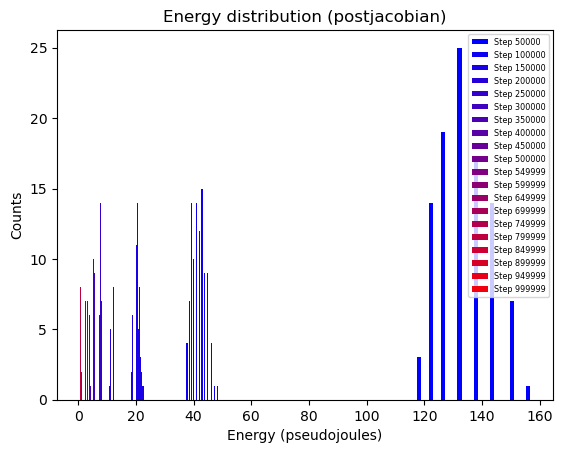

In [43]:
bin_edges_full = []
counts_full = []

# normalize
sample_dists_normalized = np.divide(sample_dists,max(sample_dists))

for i2 in range (len(checksteps)):
    postjacobian_dist_list = []
    for i in range (number_of_spheres):
    # converts to (pseudo)joules, applies jacobian
        postjacobian_num = (2.8*(10**-19))+((1/(sample_dists_normalized
                                                [i+(number_of_spheres*(i2))]**2))*(5.989*(10**-37))*(8.348*(10**35)))
        postjacobian_dist_list.append(postjacobian_num)
   # bins_approx = np.sqrt(np.round(max(postjacobian_dist_list)-min(postjacobian_dist_list),decimals=0))
    counts,bin_edges,patches = plt.hist(postjacobian_dist_list,bins=int(np.round(len(checksteps)*1.4)-i2),
                                        color=((1/len(checksteps))*i2,0,1-(1/len(checksteps))*i2,1),
    label='Step '+str(int(checksteps[i2])))
    bin_edges_full.append(bin_edges)
    counts_full.append(counts)


plt.legend(fontsize='xx-small',loc='upper right')
plt.ylabel('Counts')
plt.xlabel('Energy (pseudojoules)')
plt.title('Energy distribution (postjacobian)')
plt.savefig(str(trial_number)+'NCgrowthsim_Edist_.png',bbox_inches='tight',pad_inches=1)

In [ ]:
# lineshape definition - gaussian
def gaussian_function(xarr,center,sigma):
    return [(1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((x-center)/sigma)**2)))) for x in xarr]

def fit_gaussian_func(xarr,yarr):
    params,covariance = optimize.curve_fit(gaussian_function,xarr,yarr)
    return params

# make photo lineshape
xarr1 = np.linspace(-5,5,100)
sigma = 1
center = 0
yarr1 = (1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((xarr1-center)/sigma)**2))))

# fwhm function
def fwhm_get(yarr):
    halfmax = 0.5*(np.argmax(yarr))
    fwhm = np.argmin(np.abs(yarr[:np.argmax(yarr)]-halfmax))-np.argmin(np.abs(yarr[np.argmax(yarr):]-halfmax))
    return fwhm

fwhm_arr = []

# calculate fwhm for each peak
for i in range(len(checksteps)):
    plt.plot(np.linspace(list(bin_edges_full[i])[0],list(bin_edges_full[i])[-1],len(np.convolve(counts_full[i][:-1],yarr1)))
             ,np.convolve(counts_full[i][:-1],yarr1),color=((1/len(checksteps))*i,0,1-(1/len(checksteps))*i,1),
    label='Step '+str(int(checksteps[i])))
    fwhm_arr.append(fwhm_get(np.convolve(counts_full[i][:-1],yarr1)))
    

plt.xlabel('Energy (pseudojoules)')
plt.ylabel('Intensity')
plt.title('Spectra (postconvolution)')
plt.legend(fontsize = 'xx-small',loc='upper right')
plt.savefig(str(trial_number)+'NCgrowthsim_convolvedspec_.png',bbox_inches='tight',pad_inches=1)

In [4]:
plt.plot(checksteps,fwhm_arr)
plt.xlabel('Step')
plt.ylabel('FWHM (pseudojoules)')
plt.title('Full width half max')
plt.savefig(str(trial_number)+'NCgrowthsim_FWHM_.png',bbox_inches='tight',pad_inches=1)

NameError: name 'checksteps' is not defined